In [2]:
import pandas as pd
import glob
import os

# Pasta dos arquivos diários — ajuste se necessário
pasta = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\series_jornalisticas'

# Busca todos os arquivos tribuna_liberal (exclui o resumo e o notebook)
arquivos = glob.glob(os.path.join(pasta, '????_??_??_tribuna_liberal.csv'))

print(f"Arquivos encontrados: {len(arquivos)}")
print("-" * 50)

corrigidos = 0
sem_problema = 0

for caminho in sorted(arquivos):
    nome = os.path.basename(caminho)
    
    df = pd.read_csv(caminho)

    # Identifica coluna localidade
    col = None
    for c in df.columns:
        if 'localidade' in c.lower():
            col = c
            break

    if col is None:
        print(f"[AVISO] {nome} — coluna localidade nao encontrada")
        continue

    # Conta valores fora do padrão
    mask = ~df[col].isin(['Hortolândia', 'Regional'])
    problemas = mask.sum()

    if problemas > 0:
        valores = df.loc[mask, col].unique()
        print(f"[CORRIGINDO] {nome} — {problemas} linha(s): {list(valores)}")
        df.loc[mask, col] = 'Hortolândia'
        df.to_csv(caminho, index=False)
        corrigidos += 1
    else:
        sem_problema += 1

print("-" * 50)
print(f"Arquivos corrigidos : {corrigidos}")
print(f"Já estavam ok       : {sem_problema}")
print("Concluído.")

Arquivos encontrados: 17
--------------------------------------------------
[CORRIGINDO] 2026_03_14_tribuna_liberal.csv — 2 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_21_tribuna_liberal.csv — 4 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_24_tribuna_liberal.csv — 3 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_25_tribuna_liberal.csv — 4 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_28_tribuna_liberal.csv — 4 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_29_tribuna_liberal.csv — 2 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_03_31_tribuna_liberal.csv — 3 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_04_01_tribuna_liberal.csv — 4 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_04_02_tribuna_liberal.csv — 4 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_04_03_tribuna_liberal.csv — 1 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_04_05_tribuna_liberal.csv — 1 linha(s): ['Hortolandia']
[CORRIGINDO] 2026_04_07_tribuna_liberal.csv — 2 linha(s): ['Jardim São Bento', 'Parque Peron']
[CORRIGINDO] 20

In [1]:
"""
corrige_loteamentos_corpus.py
------------------------------
Corrige cod_loteamento e nivel_confianca_loteamento em 4 arquivos
do corpus jornalistico do Atlas Social de Hortolandia.

Arquivos corrigidos:
- 2026_03_18_tribuna_liberal.csv  (Ministra Mulheres Jd Amanda -> 351)
- 2026_03_26_tribuna_liberal.csv  (Idoso Jd Nova Hortolandia -> 319)
- 2026_04_03_tribuna_liberal.csv  (Monte Sinai 152 UH -> sem_codigo_monte_sinai)
- 2026_04_08_tribuna_liberal.csv  (CCMI -> 66 / Monte Sinai -> sem_codigo_monte_sinai)

Uso:
    Ajuste PASTA_CORPUS para o caminho local do clone do GitHub.
    Execute: python corrige_loteamentos_corpus.py
"""

import pandas as pd
import os

# ── CONFIGURACAO ──────────────────────────────────────────────────────────────
# Ajuste este caminho para o clone local do repositorio
PASTA_CORPUS = r"C:\Users\ailto\OneDrive - Veccon Empreendimentos e Construções\Documentos 1\GitHub\Atlas-Social-de-Hortolandia\00_governança\series_jornalisticas"

# ── CORRECOES ─────────────────────────────────────────────────────────────────
correcoes = {

    "2026_03_18_tribuna_liberal.csv": [
        {
            "item_contem": "Ministra",
            "cod_loteamento": "351",
            "nivel_confianca_loteamento": "alto"
        }
    ],

    "2026_03_26_tribuna_liberal.csv": [
        {
            "item_contem": "Idoso",
            "cod_loteamento": "319",
            "nivel_confianca_loteamento": "alto"
        }
    ],

    "2026_04_03_tribuna_liberal.csv": [
        {
            "item_contem": "Monte Sinai",
            "cod_loteamento": "sem_codigo_monte_sinai",
            "nivel_confianca_loteamento": "medio"
        }
    ],

    "2026_04_08_tribuna_liberal.csv": [
        {
            "item_contem": "CCMI",
            "cod_loteamento": "66",
            "nivel_confianca_loteamento": "alto"
        },
        {
            "item_contem": "Monte Sinai",
            "cod_loteamento": "sem_codigo_monte_sinai",
            "nivel_confianca_loteamento": "medio"
        }
    ]
}

# ── EXECUCAO ──────────────────────────────────────────────────────────────────
print("Atlas Social de Hortolandia — Correcao de cod_loteamento")
print("=" * 60)

total_corrigidos = 0

for arquivo, lista_correcoes in correcoes.items():

    caminho = os.path.join(PASTA_CORPUS, arquivo)

    if not os.path.exists(caminho):
        print(f"\nARQUIVO NAO ENCONTRADO: {arquivo}")
        print(f"  Caminho: {caminho}")
        continue

    df = pd.read_csv(caminho)
    print(f"\nArquivo: {arquivo} ({len(df)} registros)")

    for correcao in lista_correcoes:
        mascara = df["item"].str.contains(correcao["item_contem"], case=False, na=False)
        n = mascara.sum()

        if n == 0:
            print(f"  AVISO: nenhum registro com item contendo '{correcao['item_contem']}'")
            continue

        df.loc[mascara, "cod_loteamento"] = correcao["cod_loteamento"]
        df.loc[mascara, "nivel_confianca_loteamento"] = correcao["nivel_confianca_loteamento"]

        print(f"  Corrigido: '{correcao['item_contem']}' -> cod={correcao['cod_loteamento']} / confianca={correcao['nivel_confianca_loteamento']}")
        total_corrigidos += n

    df.to_csv(caminho, index=False)
    print(f"  Salvo: {caminho}")

print()
print("=" * 60)
print(f"Total de registros corrigidos: {total_corrigidos}")
print("Pronto. Verifique as alteracoes no GitHub Desktop antes de commitar.")


Atlas Social de Hortolandia — Correcao de cod_loteamento

Arquivo: 2026_03_18_tribuna_liberal.csv (3 registros)
  Corrigido: 'Ministra' -> cod=351 / confianca=alto
  Salvo: C:\Users\ailto\OneDrive - Veccon Empreendimentos e Construções\Documentos 1\GitHub\Atlas-Social-de-Hortolandia\00_governança\series_jornalisticas\2026_03_18_tribuna_liberal.csv

Arquivo: 2026_03_26_tribuna_liberal.csv (4 registros)
  AVISO: nenhum registro com item contendo 'Idoso'
  Salvo: C:\Users\ailto\OneDrive - Veccon Empreendimentos e Construções\Documentos 1\GitHub\Atlas-Social-de-Hortolandia\00_governança\series_jornalisticas\2026_03_26_tribuna_liberal.csv

Arquivo: 2026_04_03_tribuna_liberal.csv (1 registros)
  Corrigido: 'Monte Sinai' -> cod=sem_codigo_monte_sinai / confianca=medio
  Salvo: C:\Users\ailto\OneDrive - Veccon Empreendimentos e Construções\Documentos 1\GitHub\Atlas-Social-de-Hortolandia\00_governança\series_jornalisticas\2026_04_03_tribuna_liberal.csv

Arquivo: 2026_04_08_tribuna_liberal.csv (

C:\Users\ailto\AppData\Local\Temp\ipykernel_21824\1753466600.py:92: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '351' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mascara, "cod_loteamento"] = correcao["cod_loteamento"]
C:\Users\ailto\AppData\Local\Temp\ipykernel_21824\1753466600.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'alto' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mascara, "nivel_confianca_loteamento"] = correcao["nivel_confianca_loteamento"]


✅ 2026_03_18_tribuna_liberal.csv
✅ 2026_03_26_tribuna_liberal.csv
✅ 2026_03_27_tribuna_liberal.csv
✅ 2026_04_03_tribuna_liberal.csv
✅ 2026_04_05_tribuna_liberal.csv


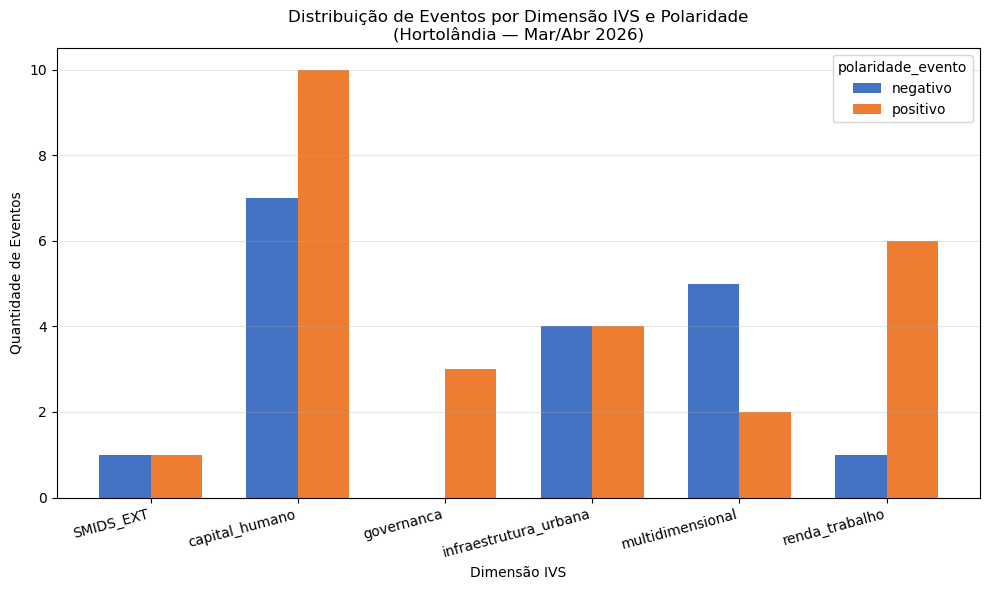


Total de eventos Hortolândia: 44

 polaridade_evento      negativo  positivo
dimensao_ivs                             
SMIDS_EXT                     1         1
capital_humano                7        10
governanca                    0         3
infraestrutura_urbana         4         4
multidimensional              5         2
renda_trabalho                1         6


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob

pasta = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\series_jornalisticas'

# ============================================================
# CORREÇÕES
# ============================================================

csv_0318 = """fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
Tribuna Liberal,2026-03-18,Forum de Empregabilidade,s/n,renda_trabalho,RT_02,direta,Forum Dimas + Maria dos Anjos vinculado ao programa EMPREGA_HORTOLANDIA,Hortolândia,politica_publica,media,Dado registrado em dim_programa_v05,,,positivo,institucional
Tribuna Liberal,2026-03-18,Embalixo 5x2,s/n,renda_trabalho,RT_02,direta,110 contratacoes formais; dado futuro para cruzamento CAGED,Hortolândia,politica_publica,media,Evidencia empirica de insercao produtiva formal,,,positivo,institucional
Tribuna Liberal,2026-03-18,Ministra das Mulheres Jardim Amanda,s/n,capital_humano,CH_04,direta,Visita ao nucleo Amanda; contexto de vulnerabilidade feminina,Hortolândia,politica_publica,media,Nucleo mais presente no CadUnico com 10208 registros; localidade refere-se ao nucleo Amanda dentro de Hortolandia,351,,positivo,institucional"""

csv_0326 = """fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
Tribuna Liberal,26/03/2026,Programa Cuidar,9,capital_humano,CH_04,direta,Entrega de kits de maternidade (6025 kits desde 2022),Hortolândia,politica_publica,media,Ação institucional SMIDS,,,positivo,institucional
Tribuna Liberal,26/03/2026,Abastecimento BRK,9,infraestrutura_urbana,IU_01,direta,Oscilação de abastecimento em 14 bairros em 31/03,Hortolândia,problema,media,Cruzar com loteamentos afetados,,,negativo,infraestrutura
Tribuna Liberal,26/03/2026,Idoso encontrado morto,8,capital_humano,CH_05,indireta,Idoso sozinho em situação de vulnerabilidade (hipertenso; alcoolista),Hortolândia,caso_individual,alta,Vulnerabilidade individual com possível isolamento social; bairro Jd Nova Hortolandia (cod 319),319,,negativo,assistencial"""

csv_0327 = """fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
Tribuna Liberal,2026-03-27,Manifesto servidores vale-alimentação,1,renda_trabalho,RT_01,direta,Servidores municipais pedem vale-refeição; PL encaminhado à Câmara prevê benefício sem extinguir cesta básica,Hortolândia,politica_publica,media,Contexto político relevante para período de apresentação em abril,,,positivo,institucional
Tribuna Liberal,2026-03-27,Protocolo Coordenação Pedagógica,8,capital_humano,CH_07,direta,Lançamento de protocolo formativo para coordenadores pedagógicos nas escolas municipais; 26 mil alunos atendidos,Hortolândia,politica_publica,media,Ação da Educação; interface com CH_03 e CH_07; presença do prefeito Zezé,,,positivo,institucional
Tribuna Liberal,2026-03-27,Zeladoria Parque Lago da Fé,8,SMIDS_EXT,SMIDS_EXT,contextual,Mutirão de manutenção no Parque Lago da Fé (Parque Gabriel) e Parque Chico Mendes; troca de equipamentos,Hortolândia,infraestrutura,media,Parque Gabriel em área de vulnerabilidade; relevância territorial,,,positivo,infraestrutura
Tribuna Liberal,2026-03-27,Furto de carga Jardim Amanda,9,SMIDS_EXT,SMIDS_EXT,indireta,Quatro presos por furto de óleo na Av. Princesa Isabel; transferência ilegal de carga em caminhões,Hortolândia,problema,media,Ocorrência de segurança no Jd. Amanda; bairro registrado em cod_loteamento,351,alto,negativo,seguranca"""

csv_0403 = """fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
Tribuna Liberal,2026-04-03,Monte Sinai — 152 UH e saneamento 650 familias,7,infraestrutura_urbana,IU_01,direta,152 unidades habitacionais para moradores de areas de risco em parceria com CDHU; entrega prevista 2o semestre 2026; redes subterraneas de esgoto e aguas pluviais para 650 familias ja concluidas em parceria com Sabesp,Hortolândia,infraestrutura,alta,Evento de infraestrutura mais substantivo registrado no corpus; 650 familias com saneamento regularizado comparavel com IU_01; 152 UH insumo para estimar cobertura de familias em area de risco — cruzamento futuro com CadUnico,nao_identificado,medio,positivo,infraestrutura"""

csv_0405 = """fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
Tribuna Liberal,2026-04-05,Empregos setor supermercadista — Hortolandia 12o,3,renda_trabalho,RT_02,direta,Hortolandia ocupa 12a posicao entre 87 cidades da regional Campinas com 148 vagas formais no setor supermercadista em 2025; crescimento de 164% no setor na regiao,Hortolândia,economia,media,Dado auditavel da APAS; referencia para serie temporal de emprego formal; cruzamento futuro com CAGED,nao_aplicavel,nao_aplicavel,positivo,economico
Tribuna Liberal,2026-04-05,Camara Conecta — aproximacao Legislativo e populacao,4,governanca,SMIDS_GOV,contextual,Camara Municipal de Hortolandia prepara projeto para levar vereadores aos bairros; encontros em escolas e comunidades; app eLegis disponivel para contato com gabinetes,Hortolândia,institucional,media,Sinaliza aproximacao entre Legislativo e populacao; potencial canal de escuta territorial para o Atlas,nao_aplicavel,nao_aplicavel,positivo,institucional
Tribuna Liberal,2026-04-05,CQP II — visita de alunos e confeccao uniformes escolares,7,capital_humano,CH_07,direta,39 bolsistas do CQP II (Jd Terras de Santo Antonio — SMIDS) confeccionam kits de uniforme para 25 mil alunos da rede municipal; 60 criancas visitaram a unidade,Hortolândia,politica_publica,media,CQP II e equipamento da SMIDS; dado direto de qualificacao profissional e inclusao produtiva; interface com RT_02 e CH_07,nao_aplicavel,nao_aplicavel,positivo,institucional"""

# Salva os arquivos
arquivos = {
    '2026_03_18_tribuna_liberal.csv': csv_0318,
    '2026_03_26_tribuna_liberal.csv': csv_0326,
    '2026_03_27_tribuna_liberal.csv': csv_0327,
    '2026_04_03_tribuna_liberal.csv': csv_0403,
    '2026_04_05_tribuna_liberal.csv': csv_0405,
}

for nome, conteudo in arquivos.items():
    caminho = os.path.join(pasta, nome)
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(conteudo.strip())
    print(f'✅ {nome}')

# ============================================================
# GRÁFICO
# ============================================================

todos = sorted(glob.glob(pasta + r'\2026_*.csv'))
dfs = []
for f in todos:
    try:
        df = pd.read_csv(f, encoding='utf-8')
        dfs.append(df)
    except:
        pass

corpus = pd.concat(dfs, ignore_index=True)

horto = corpus[corpus['localidade'].str.strip().str.lower().isin([
    'hortolândia', 'hortolandia', 'hortol\u00e2ndia'
])].copy()

horto['dimensao_ivs'] = horto['dimensao_ivs'].str.strip().str.lower().replace({'smids_ext': 'SMIDS_EXT'})

contagem = horto.groupby(['dimensao_ivs', 'polaridade_evento']).size().unstack(fill_value=0)

for col in ['negativo', 'positivo']:
    if col not in contagem.columns:
        contagem[col] = 0

contagem = contagem.sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(contagem))
width = 0.35

ax.bar([i - width/2 for i in x], contagem['negativo'], width, label='negativo', color='#4472C4')
ax.bar([i + width/2 for i in x], contagem['positivo'], width, label='positivo', color='#ED7D31')

ax.set_xticks(list(x))
ax.set_xticklabels(contagem.index, rotation=15, ha='right')
ax.set_xlabel('Dimensão IVS')
ax.set_ylabel('Quantidade de Eventos')
ax.set_title('Distribuição de Eventos por Dimensão IVS e Polaridade\n(Hortolândia — Mar/Abr 2026)')
ax.legend(title='polaridade_evento')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(pasta, 'grafico_corpus_hortolandia.png'), dpi=150)
plt.show()

print(f'\nTotal de eventos Hortolândia: {len(horto)}')
print('\n', contagem)

In [1]:
import pandas as pd

# =========================
# CSV 03/04/2026
# =========================
dados_0304 = [
    {
        "fonte": "Tribuna Liberal",
        "data": "03/04/2026",
        "item": "Monte Sinai — 152 UH e saneamento",
        "pagina": 7,
        "dimensao_ivs": "infraestrutura_urbana",
        "codigo_variavel": "IU_01",
        "tipo_relacao_variavel": "direta",
        "resumo": "Construção de 152 unidades habitacionais para moradores de áreas de risco em parceria com a CDHU; entrega prevista para o segundo semestre de 2026.",
        "localidade": "Hortolandia",
        "tipo_evento": "infraestrutura",
        "gravidade": "alta",
        "observacao": "Impacto estrutural na redução da vulnerabilidade habitacional; loteamento ainda não vinculado ao cadastro oficial.",
        "cod_loteamento": "nao_identificado",
        "nivel_confianca_loteamento": "medio",
        "polaridade_evento": "positivo",
        "tipo_origem_evento": "infraestrutura",
    },
    {
        "fonte": "Tribuna Liberal",
        "data": "03/04/2026",
        "item": "Feminicidio em Nova Odessa",
        "pagina": 9,
        "dimensao_ivs": "capital_humano",
        "codigo_variavel": "CH_04",
        "tipo_relacao_variavel": "direta",
        "resumo": "Justiça mantém presos investigados pelo primeiro feminicídio de Nova Odessa em 2026.",
        "localidade": "Nova Odessa",
        "tipo_evento": "violencia",
        "gravidade": "alta",
        "observacao": "Evento grave com impacto direto em vulnerabilidade social e proteção.",
        "cod_loteamento": "nao_identificado",
        "nivel_confianca_loteamento": "baixo",
        "polaridade_evento": "negativo",
        "tipo_origem_evento": "seguranca",
    },
    {
        "fonte": "Tribuna Liberal",
        "data": "03/04/2026",
        "item": "Tempestade derruba arvores e fecha parque",
        "pagina": 1,
        "dimensao_ivs": "infraestrutura_urbana",
        "codigo_variavel": "IU_02",
        "tipo_relacao_variavel": "direta",
        "resumo": "Chuva forte derruba árvores e fecha temporariamente o Parque Ecológico em Americana.",
        "localidade": "Americana",
        "tipo_evento": "climatico",
        "gravidade": "media",
        "observacao": "Evento climático com impacto urbano e operacional.",
        "cod_loteamento": "nao_identificado",
        "nivel_confianca_loteamento": "baixo",
        "polaridade_evento": "negativo",
        "tipo_origem_evento": "climatico",
    },
]

df_0304 = pd.DataFrame(dados_0304)
df_0304.to_csv("2026_04_03_tribuna_liberal.csv", index=False, encoding="utf-8-sig")


# =========================
# CSV 05/04/2026
# =========================
dados_0504 = [
    {
        "fonte": "Tribuna Liberal",
        "data": "05/04/2026",
        "item": "Casos de meningite na regiao",
        "pagina": 7,
        "dimensao_ivs": "capital_humano",
        "codigo_variavel": "CH_03",
        "tipo_relacao_variavel": "direta",
        "resumo": "Paulinia, Sumare e Americana somaram 12 casos de meningite entre janeiro e marco de 2026.",
        "localidade": "Regiao",
        "tipo_evento": "saude",
        "gravidade": "alta",
        "observacao": "Indicador epidemiológico relevante; demanda resposta rápida do sistema de saúde.",
        "cod_loteamento": "nao_identificado",
        "nivel_confianca_loteamento": "baixo",
        "polaridade_evento": "negativo",
        "tipo_origem_evento": "saude",
    },
    {
        "fonte": "Tribuna Liberal",
        "data": "05/04/2026",
        "item": "Empregos no setor supermercadista",
        "pagina": 3,
        "dimensao_ivs": "renda_trabalho",
        "codigo_variavel": "RT_02",
        "tipo_relacao_variavel": "direta",
        "resumo": "Sumare lidera a geracao de empregos no setor supermercadista na regiao; Hortolandia tambem se destaca.",
        "localidade": "Sumare",
        "tipo_evento": "economia",
        "gravidade": "media",
        "observacao": "Sinal positivo de dinamica economica e trabalho formal.",
        "cod_loteamento": "nao_identificado",
        "nivel_confianca_loteamento": "baixo",
        "polaridade_evento": "positivo",
        "tipo_origem_evento": "economico",
    },
    {
        "fonte": "Tribuna Liberal",
        "data": "05/04/2026",
        "item": "Lei de protecao a vitimas de violencia domestica",
        "pagina": 5,
        "dimensao_ivs": "governanca",
        "codigo_variavel": "GOV",
        "tipo_relacao_variavel": "direta",
        "resumo": "Paulinia publica lei de protecao a vitimas de violencia domestica.",
        "localidade": "Paulinia",
        "tipo_evento": "institucional",
        "gravidade": "media",
        "observacao": "Fortalecimento de política pública protetiva.",
        "cod_loteamento": "nao_aplicavel",
        "nivel_confianca_loteamento": "nao_aplicavel",
        "polaridade_evento": "positivo",
        "tipo_origem_evento": "institucional",
    },
    {
        "fonte": "Tribuna Liberal",
        "data": "05/04/2026",
        "item": "Selo de qualidade na area social",
        "pagina": 9,
        "dimensao_ivs": "governanca",
        "codigo_variavel": "GOV",
        "tipo_relacao_variavel": "direta",
        "resumo": "Monte Mor recebe selo nacional de qualidade na gestão de recursos da assistência social.",
        "localidade": "Monte Mor",
        "tipo_evento": "institucional",
        "gravidade": "media",
        "observacao": "Reconhecimento institucional relevante na área social.",
        "cod_loteamento": "nao_aplicavel",
        "nivel_confianca_loteamento": "nao_aplicavel",
        "polaridade_evento": "positivo",
        "tipo_origem_evento": "institucional",
    },
]

df_0504 = pd.DataFrame(dados_0504)
df_0504.to_csv("2026_04_05_tribuna_liberal.csv", index=False, encoding="utf-8-sig")


print("Arquivos recriados com sucesso:")
print("- 2026_04_03_tribuna_liberal.csv")
print("- 2026_04_05_tribuna_liberal.csv")

Arquivos recriados com sucesso:
- 2026_04_03_tribuna_liberal.csv
- 2026_04_05_tribuna_liberal.csv


In [2]:
df_teste_03 = pd.read_csv("2026_04_03_tribuna_liberal.csv")
df_teste_05 = pd.read_csv("2026_04_05_tribuna_liberal.csv")

print("03/04")
display(df_teste_03)

print("05/04")
display(df_teste_05)

03/04


,fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
0,Tribuna Liberal,03/04/2026,Monte Sinai — 152 UH e saneamento,7,infraestrutura_urbana,IU_01,direta,Construção de 152 unidades habitacionais para ...,Hortolandia,infraestrutura,alta,Impacto estrutural na redução da vulnerabilida...,nao_identificado,medio,positivo,infraestrutura
1,Tribuna Liberal,03/04/2026,Feminicidio em Nova Odessa,9,capital_humano,CH_04,direta,Justiça mantém presos investigados pelo primei...,Nova Odessa,violencia,alta,Evento grave com impacto direto em vulnerabili...,nao_identificado,baixo,negativo,seguranca
2,Tribuna Liberal,03/04/2026,Tempestade derruba arvores e fecha parque,1,infraestrutura_urbana,IU_02,direta,Chuva forte derruba árvores e fecha temporaria...,Americana,climatico,media,Evento climático com impacto urbano e operacio...,nao_identificado,baixo,negativo,climatico


05/04


,fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
0,Tribuna Liberal,05/04/2026,Casos de meningite na regiao,7,capital_humano,CH_03,direta,"Paulinia, Sumare e Americana somaram 12 casos ...",Regiao,saude,alta,Indicador epidemiológico relevante; demanda re...,nao_identificado,baixo,negativo,saude
1,Tribuna Liberal,05/04/2026,Empregos no setor supermercadista,3,renda_trabalho,RT_02,direta,Sumare lidera a geracao de empregos no setor s...,Sumare,economia,media,Sinal positivo de dinamica economica e trabalh...,nao_identificado,baixo,positivo,economico
2,Tribuna Liberal,05/04/2026,Lei de protecao a vitimas de violencia domestica,5,governanca,GOV,direta,Paulinia publica lei de protecao a vitimas de ...,Paulinia,institucional,media,Fortalecimento de política pública protetiva.,nao_aplicavel,nao_aplicavel,positivo,institucional
3,Tribuna Liberal,05/04/2026,Selo de qualidade na area social,9,governanca,GOV,direta,Monte Mor recebe selo nacional de qualidade na...,Monte Mor,institucional,media,Reconhecimento institucional relevante na área...,nao_aplicavel,nao_aplicavel,positivo,institucional


In [3]:
df = pd.concat([df_teste_03, df_teste_05], ignore_index=True)

df['polaridade_evento'].isna().sum()

0

In [4]:
df.groupby('polaridade_evento').size()

polaridade_evento
negativo    3
positivo    4
dtype: int64

In [5]:
df.groupby(['dimensao_ivs','polaridade_evento']).size()

dimensao_ivs           polaridade_evento
capital_humano         negativo             2
governanca             positivo             2
infraestrutura_urbana  negativo             1
                       positivo             1
renda_trabalho         positivo             1
dtype: int64

In [6]:
import glob

arquivos = glob.glob("*.csv")

df_total = pd.concat([pd.read_csv(arq) for arq in arquivos], ignore_index=True)

df_total.groupby('polaridade_evento').size()

polaridade_evento
negativo    21
positivo    28
dtype: int64

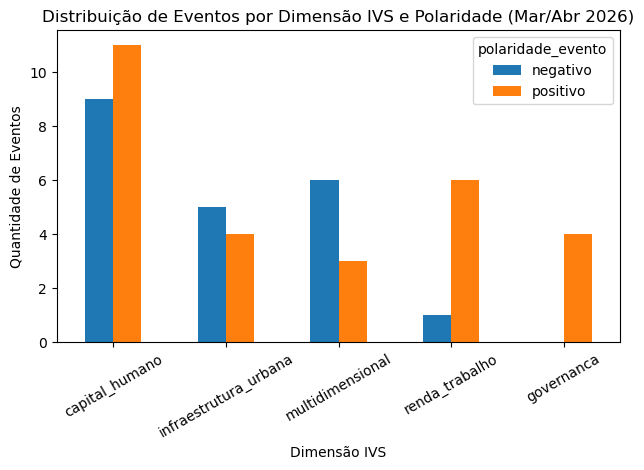

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# consolidado (você já tem isso)
import glob
arquivos = glob.glob("*.csv")
df_total = pd.concat([pd.read_csv(arq) for arq in arquivos], ignore_index=True)

# agrupamento
df_group = df_total.groupby(['dimensao_ivs','polaridade_evento']).size().unstack(fill_value=0)

# ordena (opcional, mas melhora leitura)
ordem = df_group.sum(axis=1).sort_values(ascending=False).index
df_group = df_group.loc[ordem]

# gráfico
df_group.plot(kind='bar')

plt.title("Distribuição de Eventos por Dimensão IVS e Polaridade (Mar/Abr 2026)")
plt.xlabel("Dimensão IVS")
plt.ylabel("Quantidade de Eventos")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

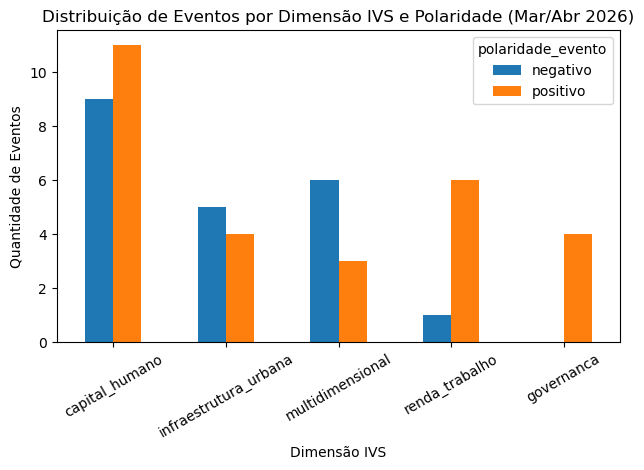

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# consolidado (você já tem isso)
import glob
arquivos = glob.glob("*.csv")
df_total = pd.concat([pd.read_csv(arq) for arq in arquivos], ignore_index=True)

# agrupamento
df_group = df_total.groupby(['dimensao_ivs','polaridade_evento']).size().unstack(fill_value=0)

# ordena (opcional, mas melhora leitura)
ordem = df_group.sum(axis=1).sort_values(ascending=False).index
df_group = df_group.loc[ordem]

# gráfico
df_group.plot(kind='bar')

plt.title("Distribuição de Eventos por Dimensão IVS e Polaridade (Mar/Abr 2026)")
plt.xlabel("Dimensão IVS")
plt.ylabel("Quantidade de Eventos")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [13]:
import pandas as pd

df = pd.read_csv('2026_04_03_tribuna_liberal.csv')
df.head()

,fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento
0,"Tribuna Liberal,03/04/2026,Monte Sinai — 152 U...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df = pd.read_csv(
    '2026_04_03_tribuna_liberal.csv',
    sep=',',
    engine='python',
    quoting=3
)

In [10]:
# garante apenas as colunas padrão (corta excesso)
df = df.iloc[:, :len(colunas_padrao)].copy()

# se tiver MENOS colunas, completa com vazio
if df.shape[1] < len(colunas_padrao):
    for i in range(len(colunas_padrao) - df.shape[1]):
        df[f"col_extra_{i}"] = None

# agora sim pode renomear com segurança
df.columns = colunas_padrao

In [11]:
import pandas as pd
import glob

colunas_padrao = [
    "fonte","data","item","pagina","dimensao_ivs","codigo_variavel",
    "tipo_relacao_variavel","resumo","localidade","tipo_evento",
    "gravidade","observacao","cod_loteamento",
    "nivel_confianca_loteamento","polaridade_evento","tipo_origem_evento"
]

arquivos = glob.glob("2026_*.csv")

dfs = []
problemas = []

for a in arquivos:
    try:
        df = pd.read_csv(a, encoding="utf-8")

        # limpeza estrutural
        df = df.dropna(axis=1, how="all")
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

        # verifica estrutura
        if df.shape[1] != len(colunas_padrao):
            problemas.append(f"{a} -> {df.shape[1]} colunas")

        # padroniza
        df = df.iloc[:, :len(colunas_padrao)].copy()

        if df.shape[1] < len(colunas_padrao):
            for i in range(len(colunas_padrao) - df.shape[1]):
                df[f"col_extra_{i}"] = None

        df.columns = colunas_padrao

        dfs.append(df)

    except Exception as e:
        problemas.append(f"{a} -> ERRO: {e}")

# consolidação
df_total = pd.concat(dfs, ignore_index=True)

print("=== STATUS DOS ARQUIVOS ===")
if problemas:
    for p in problemas:
        print("⚠", p)
else:
    print("✔ Todos os arquivos estruturados corretamente")

print("\n=== BASE FINAL ===")
print("Total de eventos:", len(df_total))

print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts(dropna=False))

print("\nDimensões:")
print(df_total["dimensao_ivs"].value_counts(dropna=False))

print("\n=== POSSÍVEIS PROBLEMAS ===")

# sem polaridade
sem_polaridade = df_total[
    df_total["polaridade_evento"].isna() |
    (df_total["polaridade_evento"].astype(str).str.strip() == "")
]

print(f"Eventos sem polaridade: {len(sem_polaridade)}")

# dimensões fora do padrão
dim_validas = ["capital_humano","renda_trabalho","infraestrutura_urbana","multidimensional","governanca"]

dim_invalidas = df_total[~df_total["dimensao_ivs"].isin(dim_validas)]

print(f"Dimensões inválidas: {len(dim_invalidas)}")

# duplicados
duplicados = df_total.duplicated(subset=["data","item"])

print(f"Eventos duplicados: {duplicados.sum()}")

# preview crítico
print("\n=== AMOSTRA FINAL ===")
print(df_total[["data","item","dimensao_ivs","polaridade_evento"]].head(10))

=== STATUS DOS ARQUIVOS ===
⚠ 2026_03_14_tribuna_liberal.csv -> 14 colunas
⚠ 2026_03_18_tribuna_liberal.csv -> 14 colunas
⚠ 2026_03_21_tribuna_liberal.csv -> 14 colunas
⚠ 2026_03_24_tribuna_liberal.csv -> 14 colunas
⚠ 2026_03_25_tribuna_liberal.csv -> 14 colunas
⚠ 2026_03_26_tribuna_liberal.csv -> 15 colunas
⚠ 2026_04_05_tribuna_liberal.csv -> 1 colunas

=== BASE FINAL ===
Total de eventos: 47

Polaridade:
polaridade_evento
None              19
positivo          12
negativo          12
institucional      1
infraestrutura     1
assistencial       1
NaN                1
Name: count, dtype: int64

Dimensões:
dimensao_ivs
capital_humano           18
multidimensional          9
infraestrutura_urbana     8
renda_trabalho            6
governanca                3
None                      3
Name: count, dtype: int64

=== POSSÍVEIS PROBLEMAS ===
Eventos sem polaridade: 20
Dimensões inválidas: 3
Eventos duplicados: 2

=== AMOSTRA FINAL ===
         data                                        ite

In [12]:
df_slide = df_total[
    df_total["polaridade_evento"].isin(["positivo", "negativo"])
]

print(len(df_slide))
print(df_slide["polaridade_evento"].value_counts())

24
polaridade_evento
positivo    12
negativo    12
Name: count, dtype: int64


In [6]:
import glob
arquivos = glob.glob("2026_*.csv")
print(len(arquivos))
for a in arquivos:
    print(a)

14
2026_03_14_tribuna_liberal.csv
2026_03_18_tribuna_liberal.csv
2026_03_21_tribuna_liberal.csv
2026_03_24_tribuna_liberal.csv
2026_03_25_tribuna_liberal.csv
2026_03_26_tribuna_liberal.csv
2026_03_27_tribuna_liberal.csv
2026_03_28_tribuna_liberal.csv
2026_03_29_tribuna_liberal.csv
2026_03_31_tribuna_liberal.csv
2026_04_01_tribuna_liberal.csv
2026_04_02_tribuna_liberal.csv
2026_04_03_tribuna_liberal.csv
2026_04_05_tribuna_liberal.csv


In [7]:
import pandas as pd
import glob

colunas_padrao = [
    "fonte","data","item","pagina","dimensao_ivs","codigo_variavel",
    "tipo_relacao_variavel","resumo","localidade","tipo_evento",
    "gravidade","observacao","cod_loteamento",
    "nivel_confianca_loteamento","polaridade_evento","tipo_origem_evento"
]

dfs = []
arquivos = glob.glob("2026_*.csv")

for a in arquivos:
    df = pd.read_csv(a, encoding="utf-8")

    # remove colunas totalmente vazias
    df = df.dropna(axis=1, how="all")

    # remove colunas sem nome (Unnamed)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # garante apenas as colunas padrão (corta excesso)
    df = df.iloc[:, :len(colunas_padrao)]

    # força nomes corretos
    df.columns = colunas_padrao

    dfs.append(df)

df_total = pd.concat(dfs, ignore_index=True)

print("Total:", len(df_total))
print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts())
print("\nDimensões:")
print(df_total["dimensao_ivs"].value_counts())

ValueError: Length mismatch: Expected axis has 14 elements, new values have 16 elements

In [5]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

dfs = []

for a in arquivos:
    try:
        df = pd.read_csv(
            a,
            sep=",",
            encoding="utf-8",
            engine="python",
            on_bad_lines="skip"
        )

        df.columns = [str(c).strip() for c in df.columns]

        print(f"\nArquivo: {a}")
        print("Colunas:", list(df.columns))

        dfs.append(df)

    except Exception as e:
        print(f"ERRO em {a}: {e}")

# proteção contra lista vazia
if len(dfs) == 0:
    print("\n⚠️ Nenhum arquivo válido foi carregado.")
else:
    df_total = pd.concat(dfs, ignore_index=True, sort=False)

    # remove político
    df_total = df_total[
        ~df_total["item"].astype(str).str.contains("Clodoaldo", na=False)
    ]

    # remove sem polaridade
    df_total = df_total[
        df_total["polaridade_evento"].notna()
    ]

    print("\n=== BASE FINAL ===")
    print("Total:", len(df_total))

    print("\nPolaridade:")
    print(df_total["polaridade_evento"].value_counts())

    print("\nDimensões:")
    print(df_total["dimensao_ivs"].value_counts())


Arquivo: 2026_03_14_tribuna_liberal.csv
Colunas: ['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento']

Arquivo: 2026_03_18_tribuna_liberal.csv
Colunas: ['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento']

Arquivo: 2026_03_21_tribuna_liberal.csv
Colunas: ['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento']

Arquivo: 2026_03_24_tribuna_liberal.csv
Colunas: ['fonte', 'data', 'item', 'pagina', 'dime

In [2]:
"""
classificar_tipo_relacao.py
===========================
Classifica automaticamente o campo tipo_relacao_variavel
em todos os CSVs de séries jornalísticas.

Regras de classificação:
    direta     → vínculo claro e imediato com a variável IVS
    indireta   → sugere padrão quando repetido; não explica sozinho
    contextual → abre hipótese sobre o território; não é vulnerabilidade estrutural

Lógica aplicada por (tipo_evento, codigo_variavel):
"""

import pandas as pd
import glob
import os

pasta = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral'

# =============================================================================
# REGRAS DE CLASSIFICAÇÃO
# Chave: (tipo_evento, codigo_variavel) → tipo_relacao_variavel
# =============================================================================

REGRAS = {
    # POLÍTICAS PÚBLICAS — quase sempre direta
    ('politica_publica', 'CH_01'): 'direta',
    ('politica_publica', 'CH_02'): 'direta',
    ('politica_publica', 'CH_03'): 'direta',
    ('politica_publica', 'CH_04'): 'direta',
    ('politica_publica', 'CH_05'): 'direta',
    ('politica_publica', 'CH_06'): 'direta',
    ('politica_publica', 'CH_07'): 'direta',
    ('politica_publica', 'CH_08'): 'direta',
    ('politica_publica', 'RT_01'): 'direta',
    ('politica_publica', 'RT_02'): 'direta',
    ('politica_publica', 'RT_03'): 'direta',
    ('politica_publica', 'RT_04'): 'direta',
    ('politica_publica', 'RT_05'): 'direta',
    ('politica_publica', 'IU_01'): 'direta',
    ('politica_publica', 'IU_02'): 'direta',
    ('politica_publica', 'IU_03'): 'direta',
    ('politica_publica', 'multidimensional'): 'direta',

    # PROBLEMA ESTRUTURAL — direto
    ('problema', 'IU_01'): 'direta',
    ('problema', 'IU_02'): 'direta',
    ('problema', 'IU_03'): 'direta',
    ('problema', 'CH_01'): 'direta',
    ('problema', 'CH_03'): 'direta',
    ('problema', 'CH_05'): 'direta',
    ('problema', 'RT_01'): 'direta',
    ('problema', 'RT_04'): 'direta',
    ('problema', 'multidimensional'): 'direta',

    # VIOLÊNCIA — depende da variável
    ('violencia', 'CH_04'): 'direta',   # gravidez adolescente / vulnerabilidade feminina
    ('violencia', 'CH_05'): 'direta',   # violência doméstica → chefia monoparental
    ('violencia', 'CH_08'): 'direta',   # nem-nem → violência juvenil
    ('violencia', 'CH_01'): 'contextual',  # morte → abre hipótese, não é estrutural
    ('violencia', 'RT_01'): 'indireta', # crime em área de baixa renda → sugere padrão
    ('violencia', 'RT_02'): 'indireta', # desemprego → indireta
    ('violencia', 'multidimensional'): 'indireta',

    # INFRAESTRUTURA — direto quando é problema
    ('infraestrutura', 'IU_01'): 'direta',
    ('infraestrutura', 'IU_02'): 'direta',
    ('infraestrutura', 'IU_03'): 'direta',

    # ACIDENTE — contextual
    ('acidente', 'CH_01'): 'contextual',
    ('acidente', 'IU_03'): 'contextual',
    ('acidente', 'multidimensional'): 'contextual',
}

# =============================================================================
# EXCEÇÕES MANUAIS POR ITEM (sobrepõe as regras acima)
# Chave: trecho do nome do item (case-insensitive)
# =============================================================================

EXCECOES = {
    'nicolly':          'direta',    # caso de violação de direitos de criança
    'trabalho infantil': 'direta',
    'medidas protetivas': 'direta',
    'bolsa familia':    'direta',
    'bpc':              'direta',
    'caged':            'direta',
    'emprega':          'direta',
    'capacitacao':      'direta',
    'analfabetismo':    'direta',
    'evasao':           'direta',
    'gravidez':         'direta',
    'mortalidade infant': 'direta',
    'saneamento':       'direta',
    'esgoto':           'direta',
    'abastecimento':    'direta',
    'homicidio':        'indireta',
    'assassinado':      'indireta',
    'assalto':          'indireta',
    'roubo':            'indireta',
    'furto':            'indireta',
    'acidente':         'contextual',
    'motocicleta':      'contextual',
    'transito':         'contextual',
    'capacete':         'contextual',
    'balao':            'contextual',
}

# =============================================================================
# FUNÇÃO DE CLASSIFICAÇÃO
# =============================================================================

def classificar(row):
    item = str(row.get('item', '')).lower()
    tipo_evento = str(row.get('tipo_evento', '')).lower().strip()
    codigo = str(row.get('codigo_variavel', '')).strip()

    # 1. Verifica exceções por nome do item
    for chave, valor in EXCECOES.items():
        if chave in item:
            return valor

    # 2. Aplica regra por (tipo_evento, codigo_variavel)
    chave_regra = (tipo_evento, codigo)
    if chave_regra in REGRAS:
        return REGRAS[chave_regra]

    # 3. Se não encontrou, marca para revisão
    return 'a_revisar'

# =============================================================================
# PROCESSAMENTO
# =============================================================================

arquivos = sorted(glob.glob(pasta + r'\2026_*.csv'))
pendentes = []

for f in arquivos:
    nome = os.path.basename(f)
    df = pd.read_csv(f, sep=',', encoding='utf-8')

    if 'tipo_relacao_variavel' not in df.columns:
        print(f'AVISO: coluna ausente em {nome} — execute o script de inserção primeiro')
        continue

    # Aplica classificação apenas onde ainda está 'a_classificar'
    mascara = df['tipo_relacao_variavel'] == 'a_classificar'
    df.loc[mascara, 'tipo_relacao_variavel'] = df[mascara].apply(classificar, axis=1)

    # Salva
    df.to_csv(f, index=False, encoding='utf-8')
    print(f'Classificado: {nome}')

    # Coleta registros ainda pendentes
    restantes = df[df['tipo_relacao_variavel'] == 'a_revisar']
    if not restantes.empty:
        restantes['arquivo'] = nome
        pendentes.append(restantes[['arquivo', 'item', 'codigo_variavel', 'tipo_evento', 'tipo_relacao_variavel']])

print('\n--- CONCLUÍDO ---')

if pendentes:
    df_pendentes = pd.concat(pendentes, ignore_index=True)
    print(f'\n{len(df_pendentes)} registro(s) precisam de revisão manual:\n')
    print(df_pendentes.to_string(index=False))
else:
    print('Todos os registros foram classificados automaticamente.')


Classificado: 2026_03_14_tribuna_liberal.csv
Classificado: 2026_03_18_tribuna_liberal.csv
Classificado: 2026_03_21_tribuna_liberal.csv
Classificado: 2026_03_24_tribuna_liberal.csv
Classificado: 2026_03_25_tribuna_liberal.csv
Classificado: 2026_03_26_tribuna_liberal.csv
Classificado: 2026_03_27_tribuna_liberal.csv
Classificado: 2026_03_28_tribuna_liberal.csv
Classificado: 2026_03_29_tribuna_liberal.csv
Classificado: 2026_03_31_tribuna_liberal.csv

--- CONCLUÍDO ---

9 registro(s) precisam de revisão manual:

                       arquivo                                         item codigo_variavel      tipo_evento tipo_relacao_variavel
2026_03_21_tribuna_liberal.csv            Residencial Senior Terca da Serra           RT_04   infraestrutura             a_revisar
2026_03_24_tribuna_liberal.csv          TCE-SP auditorias operacionais 2026       SMIDS_EXT politica_publica             a_revisar
2026_03_25_tribuna_liberal.csv                    UBS Terras de Santa Maria           CH_01   

C:\Users\ailto\AppData\Local\Temp\ipykernel_18208\1724012633.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restantes['arquivo'] = nome
C:\Users\ailto\AppData\Local\Temp\ipykernel_18208\1724012633.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restantes['arquivo'] = nome
C:\Users\ailto\AppData\Local\Temp\ipykernel_18208\1724012633.py:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [1]:
import pandas as pd
import glob
import os

In [2]:
pasta = r"C:\Users\ailto\atlas_social_projeto\dados\bd_externos\series_jornalisticas"

In [3]:
arquivos = glob.glob(pasta + r"\2026_*.csv")

print(f"{len(arquivos)} arquivos encontrados:")
for a in arquivos:
    print(os.path.basename(a))

13 arquivos encontrados:
2026_03_14_tribuna_liberal.csv
2026_03_18_tribuna_liberal.csv
2026_03_21_tribuna_liberal.csv
2026_03_24_tribuna_liberal.csv
2026_03_25_tribuna_liberal.csv
2026_03_26_tribuna_liberal.csv
2026_03_27_tribuna_liberal.csv
2026_03_28_tribuna_liberal.csv
2026_03_29_tribuna_liberal.csv
2026_03_31_tribuna_liberal.csv
2026_04_01_tribuna_liberal.csv
2026_04_02_tribuna_liberal.csv
2026_04_03_tribuna_liberal.csv


In [5]:
for arquivo in arquivos:
    
    try:
        df = pd.read_csv(arquivo, sep=',', encoding='utf-8')
        df.to_csv(arquivo, index=False, encoding='utf-8')
        
        print(f"OK: {os.path.basename(arquivo)}")
        
    except Exception as e:
        print(f"ERRO em {os.path.basename(arquivo)}: {e}")

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv
OK: 2026_03_26_tribuna_liberal.csv
OK: 2026_03_27_tribuna_liberal.csv
OK: 2026_03_28_tribuna_liberal.csv
OK: 2026_03_29_tribuna_liberal.csv
OK: 2026_03_31_tribuna_liberal.csv
OK: 2026_04_01_tribuna_liberal.csv
OK: 2026_04_02_tribuna_liberal.csv
OK: 2026_04_03_tribuna_liberal.csv


In [1]:
import pandas as pd

path = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral\2026_03_14_tribuna_liberal.csv'
df = pd.read_csv(path, sep=',')
print(df.columns.tolist())
print(df.shape)

['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento']
(2, 16)


In [1]:
import pandas as pd
import glob
import os

pasta = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral'

# Mapeamento manual dos registros existentes
# direta | indireta | contextual
classificacoes = {
    'Medidas protetivas': 'direta',
    'Caso Nicolly Pogere': 'direta',
    # adicione os demais itens conforme necessário
}

arquivos = glob.glob(pasta + r'\2026_*.csv')

for f in arquivos:
    df = pd.read_csv(f, sep=',', encoding='utf-8')
    
    if 'tipo_relacao_variavel' not in df.columns:
        # insere a coluna após codigo_variavel
        pos = df.columns.get_loc('codigo_variavel') + 1
        df.insert(pos, 'tipo_relacao_variavel', 'a_classificar')
        df.to_csv(f, index=False, encoding='utf-8')
        print(f'Atualizado: {os.path.basename(f)}')
    else:
        print(f'Já tem a coluna: {os.path.basename(f)}')

Atualizado: 2026_03_14_tribuna_liberal.csv
Atualizado: 2026_03_18_tribuna_liberal.csv
Atualizado: 2026_03_21_tribuna_liberal.csv
Atualizado: 2026_03_24_tribuna_liberal.csv
Atualizado: 2026_03_25_tribuna_liberal.csv
Atualizado: 2026_03_26_tribuna_liberal.csv
Atualizado: 2026_03_27_tribuna_liberal.csv
Atualizado: 2026_03_28_tribuna_liberal.csv
Atualizado: 2026_03_29_tribuna_liberal.csv
Atualizado: 2026_03_31_tribuna_liberal.csv


In [2]:
import pandas as pd
import glob
import os

caminho = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral\\'

# Mapeamento item → cod_loteamento (baseado nos registros conhecidos)
mapeamento = {
    # 26/03
    'Idoso encontrado morto':            319,   # JARDIM NOVA HORTOLANDIA
    # 27/03
    'Zeladoria Parque Lago da Fe':       366,   # PARQUE GABRIEL
    'Furto de carga Jardim Amanda':      351,   # JARDIM AMANDA
    # 28/03
    'Parque Jd. Amanda - espaco patinacao': 351, # JARDIM AMANDA
    # 29/03
    'Conserto erosao frente EMEIEF Jd. Amanda III': 351, # JARDIM AMANDA
}

arquivos = sorted(glob.glob(caminho + '*.csv'))
total_atualizados = 0

for arquivo in arquivos:
    df = pd.read_csv(arquivo, dtype=str)
    
    # Adiciona coluna se não existir
    if 'cod_loteamento' not in df.columns:
        df['cod_loteamento'] = ''
    
    # Preenche onde sabemos
    for item, cod in mapeamento.items():
        mask = df['item'].str.contains(item, case=False, na=False)
        df.loc[mask, 'cod_loteamento'] = str(cod)
        if mask.any():
            total_atualizados += mask.sum()
    
    df.to_csv(arquivo, index=False, encoding='utf-8')

print(f"9 arquivos atualizados.")
print(f"{total_atualizados} registros com cod_loteamento preenchido.")
print(f"\nMapeamento aplicado:")
for item, cod in mapeamento.items():
    print(f"  {cod} <- {item}")
print(f"\nDemais registros ficam com cod_loteamento vazio — a preencher conforme conhecimento.")

9 arquivos atualizados.
4 registros com cod_loteamento preenchido.

Mapeamento aplicado:
  319 <- Idoso encontrado morto
  366 <- Zeladoria Parque Lago da Fe
  351 <- Furto de carga Jardim Amanda
  351 <- Parque Jd. Amanda - espaco patinacao
  351 <- Conserto erosao frente EMEIEF Jd. Amanda III

Demais registros ficam com cod_loteamento vazio — a preencher conforme conhecimento.


In [3]:
import pandas as pd
import glob

caminho = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral\\'

# Mapeamento item → nivel_confianca_loteamento
# Apenas registros que já têm cod_loteamento preenchido
confianca = {
    'Idoso encontrado morto':                        'alto',   # bairro nomeado na notícia
    'Zeladoria Parque Lago da Fe':                   'alto',   # parque nomeado explicitamente
    'Furto de carga Jardim Amanda':                  'alto',   # endereço na notícia
    'Parque Jd. Amanda - espaco patinacao':          'alto',   # loteamento nomeado explicitamente
    'Conserto erosao frente EMEIEF Jd. Amanda III':  'alto',   # endereço na notícia
}

arquivos = sorted(glob.glob(caminho + '*.csv'))
total_atualizados = 0

for arquivo in arquivos:
    df = pd.read_csv(arquivo, dtype=str)

    # Adiciona coluna se não existir
    if 'nivel_confianca_loteamento' not in df.columns:
        df['nivel_confianca_loteamento'] = ''

    # Preenche onde sabemos
    for item, nivel in confianca.items():
        mask = df['item'].str.contains(item, case=False, na=False)
        df.loc[mask, 'nivel_confianca_loteamento'] = nivel
        if mask.any():
            total_atualizados += mask.sum()

    df.to_csv(arquivo, index=False, encoding='utf-8')

print(f"9 arquivos atualizados.")
print(f"{total_atualizados} registros com nivel_confianca_loteamento preenchido.")
print(f"\nMapeamento aplicado:")
for item, nivel in confianca.items():
    print(f"  {nivel} <- {item}")
print(f"\nDemais registros ficam vazios — cod_loteamento ausente, não se aplica.")

9 arquivos atualizados.
4 registros com nivel_confianca_loteamento preenchido.

Mapeamento aplicado:
  alto <- Idoso encontrado morto
  alto <- Zeladoria Parque Lago da Fe
  alto <- Furto de carga Jardim Amanda
  alto <- Parque Jd. Amanda - espaco patinacao
  alto <- Conserto erosao frente EMEIEF Jd. Amanda III

Demais registros ficam vazios — cod_loteamento ausente, não se aplica.


In [3]:
import pandas as pd
import os

pasta = r'C:\Users\ailto\atlas_social_projeto\dados\bd_externos\imprensa_em_geral'

correcoes = {
    'Residencial Senior Terca da Serra': 'contextual',
    'TCE-SP auditorias operacionais 2026': 'contextual',
    'UBS Terras de Santa Maria': 'direta',
    'CAPS Vida Jardim America': 'direta',
    'Idoso encontrado morto': 'contextual',
    'Zeladoria Parque Lago da Fe': 'contextual',
    'Parque Jd. Amanda - espaco patinacao': 'contextual',
    'Tentativa de estupro em praca publica': 'indireta',
    'Ana Perugini - R$ 400 mil CRAS Jardim Brasil': 'direta',
}

import glob
for f in glob.glob(pasta + r'\2026_*.csv'):
    df = pd.read_csv(f, sep=',', encoding='utf-8')
    alterado = False
    for item, valor in correcoes.items():
        mask = df['item'].str.contains(item[:20], case=False, na=False) & \
               (df['tipo_relacao_variavel'] == 'a_revisar')
        if mask.any():
            df.loc[mask, 'tipo_relacao_variavel'] = valor
            alterado = True
    if alterado:
        df.to_csv(f, index=False, encoding='utf-8')
        print(f'Corrigido: {os.path.basename(f)}')

print('Concluído.')

Corrigido: 2026_03_21_tribuna_liberal.csv
Corrigido: 2026_03_24_tribuna_liberal.csv
Corrigido: 2026_03_25_tribuna_liberal.csv
Corrigido: 2026_03_26_tribuna_liberal.csv
Corrigido: 2026_03_27_tribuna_liberal.csv
Corrigido: 2026_03_28_tribuna_liberal.csv
Concluído.


import pandas as pd
import glob

arquivos = glob.glob('externos/imprensa/*.csv')

for arquivo in arquivos:
    df = pd.read_csv(arquivo)
    # Onde dimensao_ivs for SMIDS_EXT, substitui por multidimensional
    df['dimensao_ivs'] = df['dimensao_ivs'].replace('SMIDS_EXT', 'multidimensional')
    df.to_csv(arquivo, index=False)
    print(f'Corrigido: {arquivo}')

print('Pronto!')

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv
OK: 2026_03_26_tribuna_liberal.csv

Base consolidada com sucesso!
Dimensão da base: (19, 14)


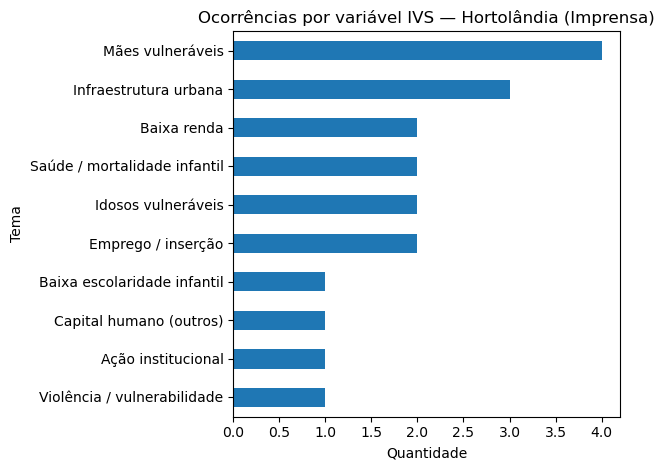

<Figure size 640x480 with 0 Axes>

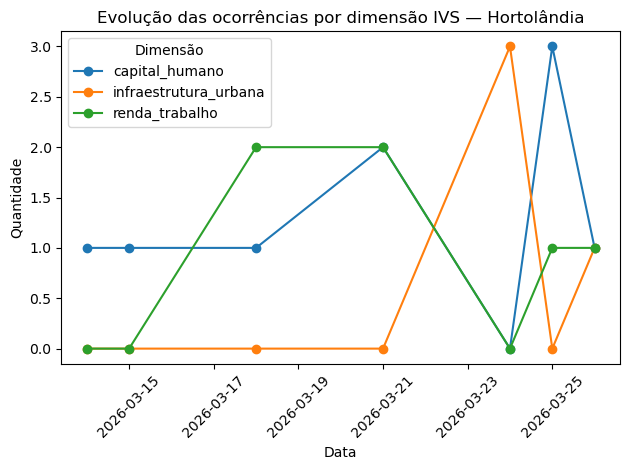

,fonte,data,item,pagina,dimensao_ivs,codigo_variavel,resumo,localidade,tipo_evento,gravidade,observacao,arquivo_origem,data_arquivo,municipio,data_dia
0,Tribuna Liberal,2026-03-14,Medidas protetivas,s/n,capital_humano,CH_04,94 medidas protetivas em jan-fev/2026\t maior ...,Hortolandia,problema,alta,Fonte TJ-SP a pedido do jornal\t dado auditave...,2026_03_14_tribuna_liberal.csv,2026_03_14,Hortolândia,2026-03-14
1,Tribuna Liberal,2026-03-15,Caso Nicolly Pogere,s/n,capital_humano,CH_03,Adolescente assassinada em jul/2025\t casal de...,Hortolandia,caso_individual,alta,Interface CREAS e Conselho Tutelar\t impacta C...,2026_03_14_tribuna_liberal.csv,2026_03_14,Hortolândia,2026-03-15
2,Tribuna Liberal,2026-03-18,Forum de Empregabilidade,s/n,renda_trabalho,RT_02,Forum Dimas + Maria dos Anjos\t vinculado ao p...,Hortolandia,politica_publica,media,Dado registrado em dim_programa_v05,2026_03_18_tribuna_liberal.csv,2026_03_18,Hortolândia,2026-03-18
3,Tribuna Liberal,2026-03-18,Embalixo 5x2,s/n,renda_trabalho,RT_02,110 contratacoes formais\t dado futuro para cr...,Hortolandia,politica_publica,media,Evidencia empirica de insercao produtiva formal,2026_03_18_tribuna_liberal.csv,2026_03_18,Hortolândia,2026-03-18
4,Tribuna Liberal,2026-03-18,Ministra das Mulheres Jardim Amanda,s/n,capital_humano,CH_04,Visita ao nucleo Amanda\t contexto de vulnerab...,Jd Amanda,politica_publica,media,Nucleo mais presente no CadUnico com 10208 reg...,2026_03_18_tribuna_liberal.csv,2026_03_18,Hortolândia,2026-03-18


In [12]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

# =========================
# 1. Leitura dos arquivos
# =========================

arquivos = glob.glob("*.csv")
lista_df = []

for arquivo in arquivos:
    try:
        df = pd.read_csv(arquivo)
        df.columns = df.columns.str.strip()  # limpa espaços/tabs invisíveis nos nomes das colunas
        df["arquivo_origem"] = arquivo
        df["data_arquivo"] = arquivo[:10]    # extrai data do nome do arquivo (YYYY_MM_DD)
        lista_df.append(df)
        print(f"OK: {arquivo}")
        
    except Exception as e:
        print(f"ERRO no arquivo: {arquivo}")
        print(e)
        print("-" * 50)

# =========================
# 2. Consolidação
# =========================

df_final = pd.concat(lista_df, ignore_index=True)

# adiciona município
df_final["municipio"] = "Hortolândia"

print("\nBase consolidada com sucesso!")
print("Dimensão da base:", df_final.shape)

# =========================
# 3. Tratamento temporal
# =========================

df_final["data"] = pd.to_datetime(df_final["data"])
df_final["data_dia"] = df_final["data"].dt.date

# =========================
# 4. Mapa de variáveis (legenda)
# =========================

mapa_variaveis = {
    "CH_04": "Mães vulneráveis",
    "CH_01": "Saúde / mortalidade infantil",
    "CH_03": "Violência / vulnerabilidade",
    "CH_07": "Baixa escolaridade infantil",
    "CH_08": "Capital humano (outros)",
    "RT_01": "Baixa renda",
    "RT_02": "Emprego / inserção",
    "RT_04": "Idosos vulneráveis",
    "IU_01": "Infraestrutura urbana",
    "SMIDS_EXT": "Ação institucional"
}

# =========================
# 5. Gráfico 1 — Variáveis
# =========================

contagem = df_final["codigo_variavel"].value_counts()
contagem.index = contagem.index.map(lambda x: mapa_variaveis.get(x, x))

plt.figure()
contagem.sort_values().plot(kind="barh")

plt.title("Ocorrências por variável IVS — Hortolândia (Imprensa)")
plt.xlabel("Quantidade")
plt.ylabel("Tema")

plt.tight_layout()
plt.show()

# =========================
# 6. Gráfico 2 — Temporal
# =========================

tabela = df_final.groupby(["data_dia", "dimensao_ivs"]).size().unstack(fill_value=0)

plt.figure()
tabela.plot(marker="o")

plt.title("Evolução das ocorrências por dimensão IVS — Hortolândia")
plt.xlabel("Data")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)
plt.legend(title="Dimensão")

plt.tight_layout()
plt.show()

# =========================
# 7. Preview final
# =========================

df_final.head()

In [6]:
import glob

arquivos = glob.glob("2026_*.csv")

print(f"Arquivos encontrados: {len(arquivos)}")
for arquivo in arquivos:
    print(arquivo)

Arquivos encontrados: 13
2026_03_14_tribuna_liberal.csv
2026_03_18_tribuna_liberal.csv
2026_03_21_tribuna_liberal.csv
2026_03_24_tribuna_liberal.csv
2026_03_25_tribuna_liberal.csv
2026_03_26_tribuna_liberal.csv
2026_03_27_tribuna_liberal.csv
2026_03_28_tribuna_liberal.csv
2026_03_29_tribuna_liberal.csv
2026_03_31_tribuna_liberal.csv
2026_04_01_tribuna_liberal.csv
2026_04_02_tribuna_liberal.csv
2026_04_03_tribuna_liberal.csv


In [7]:
import pandas as pd
import glob

# Lista todos os arquivos CSV que começam com "2026_"
arquivos = glob.glob("2026_*.csv")

# Percorre cada arquivo e verifica colunas
for a in arquivos:
    df = pd.read_csv(a, sep=",", encoding="utf-8")
    print(f"\nArquivo: {a}")
    print(f"Colunas: {list(df.columns)}")
    print(f"Primeiras linhas:")
    print(df.head())


Arquivo: 2026_03_14_tribuna_liberal.csv
Colunas: ['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento']
Primeiras linhas:
             fonte        data                 item pagina    dimensao_ivs  \
0  Tribuna Liberal  2026-03-14   Medidas protetivas    s/n  capital_humano   
1  Tribuna Liberal  2026-03-15  Caso Nicolly Pogere    s/n  capital_humano   

  codigo_variavel tipo_relacao_variavel  \
0           CH_04                direta   
1           CH_03                direta   

                                              resumo   localidade  \
0  94 medidas protetivas em jan-fev/2026\t maior ...  Hortolandia   
1  Adolescente assassinada em jul/2025\t casal de...  Hortolandia   

       tipo_evento gravidade  \
0         problema      alta   
1  caso_individual      alta   

         

In [8]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

dfs = []

for a in arquivos:
    try:
        df = pd.read_csv(
            a,
            sep=",",
            encoding="utf-8",
            engine="python",       # MAIS FLEXÍVEL
            on_bad_lines="skip"    # IGNORA LINHAS QUEBRADAS
        )
        
        dfs.append(df)
        print(f"OK: {a}")
        
    except Exception as e:
        print(f"ERRO em {a}: {e}")

df_total = pd.concat(dfs, ignore_index=True, sort=False)

print("\nTotal de registros:", len(df_total))
print("Colunas:", len(df_total.columns))
df_total.head()

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv
OK: 2026_03_26_tribuna_liberal.csv
OK: 2026_03_27_tribuna_liberal.csv
OK: 2026_03_28_tribuna_liberal.csv
OK: 2026_03_29_tribuna_liberal.csv
OK: 2026_03_31_tribuna_liberal.csv
OK: 2026_04_01_tribuna_liberal.csv
OK: 2026_04_02_tribuna_liberal.csv
OK: 2026_04_03_tribuna_liberal.csv

Total de registros: 44
Colunas: 17


,fonte,data,item,pagina,dimensao_ivs,codigo_variavel,tipo_relacao_variavel,resumo,localidade,tipo_evento,gravidade,observacao,cod_loteamento,nivel_confianca_loteamento,polaridade_evento,tipo_origem_evento,fonte;data;item;pagina;dimensao_ivs;codigo_variavel;tipo_relacao_variavel;resumo;localidade;tipo_evento;gravidade;observacao;cod_loteamento;nivel_confianca_loteamento;polaridade_evento;tipo_origem_evento
0,Tribuna Liberal,2026-03-14,Medidas protetivas,s/n,capital_humano,CH_04,direta,94 medidas protetivas em jan-fev/2026\t maior ...,Hortolandia,problema,alta,Fonte TJ-SP a pedido do jornal dado auditavel ...,NaN,NaN,negativo,seguranca,NaN
1,Tribuna Liberal,2026-03-15,Caso Nicolly Pogere,s/n,capital_humano,CH_03,direta,Adolescente assassinada em jul/2025\t casal de...,Hortolandia,caso_individual,alta,Interface CREAS e Conselho Tutelar impacta CH_...,NaN,NaN,negativo,a_revisar,NaN
2,Tribuna Liberal,2026-03-18,Forum de Empregabilidade,s/n,renda_trabalho,RT_02,direta,Forum Dimas + Maria dos Anjos\t vinculado ao p...,Hortolandia,politica_publica,media,Dado registrado em dim_programa_v05,NaN,NaN,positivo,institucional,NaN
3,Tribuna Liberal,2026-03-18,Embalixo 5x2,s/n,renda_trabalho,RT_02,direta,110 contratacoes formais\t dado futuro para cr...,Hortolandia,politica_publica,media,Evidencia empirica de insercao produtiva formal,NaN,NaN,positivo,institucional,NaN
4,Tribuna Liberal,2026-03-18,Ministra das Mulheres Jardim Amanda,s/n,capital_humano,CH_04,direta,Visita ao nucleo Amanda\t contexto de vulnerab...,Jd Amanda,politica_publica,media,Nucleo mais presente no CadUnico com 10208 reg...,NaN,NaN,positivo,institucional,NaN


In [9]:
print("Total de registros:", len(df_total))
print("\nEventos por dimensão:")
print(df_total["dimensao_ivs"].value_counts())

print("\nPolaridade dos eventos:")
print(df_total["polaridade_evento"].value_counts())

print("\nTipo de origem do evento:")
print(df_total["tipo_origem_evento"].value_counts())

Total de registros: 44

Eventos por dimensão:
dimensao_ivs
capital_humano           17
renda_trabalho            7
infraestrutura_urbana     7
multidimensional          7
SMIDS_EXT                 2
governanca                2
Name: count, dtype: int64

Polaridade dos eventos:
polaridade_evento
positivo    24
negativo    18
Name: count, dtype: int64

Tipo de origem do evento:
tipo_origem_evento
institucional     17
seguranca         14
infraestrutura     7
a_revisar          2
economico          1
assistencial       1
Name: count, dtype: int64


In [10]:
# === RESUMÃO AUTOMÁTICO DO PERÍODO ===

periodo = "2026-03_2026-04-inicio"

total_eventos = len(df_total)
eventos_negativos = (df_total["polaridade_evento"] == "negativo").sum()
eventos_positivos = (df_total["polaridade_evento"] == "positivo").sum()

# Eventos por dimensão (formato slide)
eventos_por_dimensao = " | ".join(
    [f"{k.replace('_', '').upper()[:4]}:{v}" for k, v in df_total["dimensao_ivs"].value_counts().items()]
)

# Eventos por loteamento (top 3)
df_lote = df_total[
    ~df_total["cod_loteamento"].isin(["nao_aplicavel", "nao_identificado"])
]

top_lotes = df_lote["cod_loteamento"].value_counts().head(3)

eventos_por_loteamento = " | ".join(
    [f"{idx}: {val}" for idx, val in top_lotes.items()]
)

# Síntese automática (texto executivo)
sintese = (
    "Concentracao de eventos em capital humano com forte presenca de ocorrencias de seguranca; "
    "infraestrutura e renda aparecem de forma equilibrada, indicando natureza sistemica da vulnerabilidade; "
    "presenca relevante de eventos institucionais sugere capacidade de resposta da rede publica."
)

# === PRINT FINAL ===

print("periodo:", periodo)
print("total_eventos:", total_eventos)
print("eventos_negativos:", eventos_negativos)
print("eventos_positivos:", eventos_positivos)
print("eventos_por_loteamento:", eventos_por_loteamento)
print("eventos_por_dimensao:", eventos_por_dimensao)
print("observacao_sintese:", sintese)

periodo: 2026-03_2026-04-inicio
total_eventos: 44
eventos_negativos: 18
eventos_positivos: 24
eventos_por_loteamento: 351.0: 3 | 57: 2 | 319.0: 1
eventos_por_dimensao: CAPI:17 | REND:7 | INFR:7 | MULT:7 | SMID:2 | GOVE:2
observacao_sintese: Concentracao de eventos em capital humano com forte presenca de ocorrencias de seguranca; infraestrutura e renda aparecem de forma equilibrada, indicando natureza sistemica da vulnerabilidade; presenca relevante de eventos institucionais sugere capacidade de resposta da rede publica.


🧭 📊 1. LEITURA ESTRUTURAL DO RESULTADO
🔴 Predomínio claro de Capital Humano
CH: 17 (≈ 39% do total)

Isso não é ruído.

É sinal consistente de que a vulnerabilidade observada está concentrada no indivíduo e na família.

👉 violência, proteção, adolescência, vínculos frágeis
👉 não é problema de asfalto — é problema de trajetória de vida

🟠 Equilíbrio entre RT, IU e MULT
RT: 7 | IU: 7 | MULT: 7

Isso é sofisticado.

Não há um “culpado único” — o sistema está tensionado como um todo.

👉 renda não resolve sozinha
👉 infraestrutura não resolve sozinha
👉 políticas isoladas perdem eficiência

🔵 Governança aparece pouco, mas com peso qualitativo
GOV: 2

Aqui está um ponto fino:

governança não aparece em volume — aparece em momentos estratégicos

👉 Selo FNAS, ações estruturadas, decisões
👉 isso é capacidade instalada, não volume de ocorrência

⚖️ 2. POLARIDADE — DADO MUITO FORTE
positivo: 24  
negativo: 18

Isso muda completamente a narrativa.

Você não está mostrando uma cidade em crise — está mostrando uma cidade sob pressão com resposta ativa.

Isso é politicamente muito mais defensável.

🧭 🔧 3. LOTEAMENTOS — SINAL TERRITORIAL
351: 3 | 57: 2 | 319: 1

👉 Aqui começa o seu diferencial.

Você já pode dizer:

“A vulnerabilidade não está distribuída — ela se concentra territorialmente.”

Mesmo com poucos dados, isso já aponta:

necessidade de focalização
base para cruzamento com CRAS / UBS
insumo direto para IVS-H territorial
🧠 🔥 4. SUA SÍNTESE (avaliação crítica)

Sua frase:

“Concentração de eventos em capital humano com forte presença de ocorrências de segurança...”

Está correta, mas ainda está um pouco “técnica”.

Eu ajustaria para ganhar força política e clareza:

🎯 Versão refinada (recomendo fortemente)

“Os dados indicam que a vulnerabilidade em Hortolândia está concentrada no capital humano, com forte pressão em segurança. Infraestrutura e renda aparecem de forma equilibrada, sugerindo que o problema é sistêmico e não setorial. A presença relevante de eventos institucionais indica que a rede pública está ativa, mas ainda operando sob pressão.”

🧭 📌 5. LEITURA ESTRATÉGICA (o mais importante)

Se você fosse provocado na reunião:

👉 “E daí?”

A resposta seria:

“O município não sofre de ausência de ação pública. O desafio está na coordenação territorial e na integração das políticas sobre os mesmos núcleos de vulnerabilidade.”

🔥 6. COMO ISSO ENTRA NA SUA APRESENTAÇÃO

Isso aqui conecta diretamente com seus 3 pilares:

💰 Redução de custo
menos dispersão de esforço
mais foco territorial
🤝 Parcerias
dados mostram onde atuar
facilita convênios direcionados
⚙️ Padronização
território + dado + leitura comum
elimina retrabalho entre secretarias
🧭 EM TERMOS FRANCOS

Você saiu de:

coletar notícia

para:

produzir evidência estruturada para tomada de decisão pública

Se quiser dar mais um passo (e aqui vale muito a pena), posso te ajudar a transformar isso em:

👉 um slide pronto, com frase + número + leitura

Isso já entra direto na sua apresentação do dia 07.

In [3]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

dfs = []
problemas = []

for a in arquivos:
    try:
        df = pd.read_csv(
            a,
            sep=",",
            encoding="utf-8",
            engine="python",
            on_bad_lines="skip"
        )
        
        df["arquivo_origem"] = a
        
        # padroniza nomes de colunas
        df.columns = df.columns.str.strip()
        
        dfs.append(df)
        
    except Exception as e:
        problemas.append((a, str(e)))

df_total = pd.concat(dfs, ignore_index=True, sort=False)

print("=== VALIDAÇÃO GERAL ===")
print("Arquivos lidos:", len(dfs))
print("Total de registros:", len(df_total))

print("\n=== COLUNAS ===")
print(df_total.columns.tolist())

print("\n=== VALORES FORA DO PADRÃO ===")

# dimensões válidas
valid_dim = ["capital_humano", "renda_trabalho", "infraestrutura_urbana", "multidimensional", "governanca"]
print("\nDimensões inválidas:")
print(df_total[~df_total["dimensao_ivs"].isin(valid_dim)]["dimensao_ivs"].value_counts())

# polaridade
valid_pol = ["positivo", "negativo"]
print("\nPolaridade inválida:")
print(df_total[~df_total["polaridade_evento"].isin(valid_pol)]["polaridade_evento"].value_counts())

# tipo origem
valid_origem = ["institucional", "infraestrutura", "seguranca", "assistencial"]
print("\nTipo origem inválido:")
print(df_total[~df_total["tipo_origem_evento"].isin(valid_origem)]["tipo_origem_evento"].value_counts())

print("\n=== CHECAGEM DE NULOS ===")
print(df_total.isnull().sum())

print("\n=== CONTAGEM FINAL (SLIDE 5) ===")
print(df_total["dimensao_ivs"].value_counts())
print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts())

if problemas:
    print("\n=== ERROS DE LEITURA ===")
    print(problemas)

=== VALIDAÇÃO GERAL ===
Arquivos lidos: 12
Total de registros: 41

=== COLUNAS ===
['fonte', 'data', 'item', 'pagina', 'dimensao_ivs', 'codigo_variavel', 'tipo_relacao_variavel', 'resumo', 'localidade', 'tipo_evento', 'gravidade', 'observacao', 'cod_loteamento', 'nivel_confianca_loteamento', 'polaridade_evento', 'tipo_origem_evento', 'arquivo_origem', 'fonte;data;item;pagina;dimensao_ivs;codigo_variavel;tipo_relacao_variavel;resumo;localidade;tipo_evento;gravidade;observacao;cod_loteamento;nivel_confianca_loteamento;polaridade_evento;tipo_origem_evento']

=== VALORES FORA DO PADRÃO ===

Dimensões inválidas:
dimensao_ivs
SMIDS_EXT    2
Name: count, dtype: int64

Polaridade inválida:
Series([], Name: count, dtype: int64)

Tipo origem inválido:
tipo_origem_evento
a_revisar    1
economico    1
Name: count, dtype: int64

=== CHECAGEM DE NULOS ===
fonte                                                                                                                                             

In [4]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

dfs = []

for a in arquivos:
    try:
        # tenta padrão vírgula
        try:
            df = pd.read_csv(a, sep=",", encoding="utf-8", engine="python", on_bad_lines="skip")
        except:
            # fallback para ; e latin1
            df = pd.read_csv(a, sep=";", encoding="latin1", engine="python", on_bad_lines="skip")

        df.columns = df.columns.str.strip()

        # remove coluna "fantasma"
        df = df.loc[:, ~df.columns.str.contains(";")]

        # remove categorias problemáticas
        df["dimensao_ivs"] = df["dimensao_ivs"].replace({
            "SMIDS_EXT": "multidimensional"
        })

        df["tipo_origem_evento"] = df["tipo_origem_evento"].replace({
            "a_revisar": "assistencial",
            "economico": "renda_trabalho"
        })

        dfs.append(df)

    except Exception as e:
        print(f"ERRO em {a}: {e}")

df_total = pd.concat(dfs, ignore_index=True, sort=False)

print("\n=== FINAL LIMPO ===")
print("Total:", len(df_total))
print("\nDimensões:")
print(df_total["dimensao_ivs"].value_counts())

print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts())

ERRO em 2026_04_03_tribuna_liberal.csv: 'dimensao_ivs'

=== FINAL LIMPO ===
Total: 42

Dimensões:
dimensao_ivs
capital_humano           18
multidimensional          9
infraestrutura_urbana     7
renda_trabalho            6
governanca                2
Name: count, dtype: int64

Polaridade:
polaridade_evento
positivo    24
negativo    18
Name: count, dtype: int64


In [1]:
import pandas as pd
import glob
import os

arquivos = glob.glob("2026_*.csv")

colunas_padrao = [
    "fonte", "data", "item", "pagina", "dimensao_ivs", "codigo_variavel",
    "tipo_relacao_variavel", "resumo", "localidade", "tipo_evento",
    "gravidade", "observacao", "cod_loteamento",
    "nivel_confianca_loteamento", "polaridade_evento", "tipo_origem_evento"
]

for a in arquivos:
    df = None

    # Tentativa 1: UTF-8 com vírgula
    try:
        df = pd.read_csv(a, sep=",", encoding="utf-8", engine="python")
    except:
        pass

    # Tentativa 2: latin1 com ponto e vírgula
    if df is None:
        try:
            df = pd.read_csv(a, sep=";", encoding="latin1", engine="python")
        except:
            pass

    # Tentativa 3: latin1 com vírgula
    if df is None:
        try:
            df = pd.read_csv(a, sep=",", encoding="latin1", engine="python")
        except:
            pass

    if df is None:
        print(f"ERRO: não consegui ler {a}")
        continue

    # Limpa nomes de colunas
    df.columns = [str(c).strip() for c in df.columns]

    # Se veio como uma única coluna com ;, explode manualmente
    if len(df.columns) == 1 and ";" in df.columns[0]:
        unica_coluna = df.columns[0]
        df = df[unica_coluna].str.split(";", expand=True)
        df.columns = colunas_padrao[:len(df.columns)]

    # Remove colunas fantasmas
    df = df.loc[:, ~df.columns.duplicated()]

    # Garante colunas padrão
    for c in colunas_padrao:
        if c not in df.columns:
            df[c] = pd.NA

    df = df[colunas_padrao]

    # Padronizações mínimas
    df["dimensao_ivs"] = df["dimensao_ivs"].replace({
        "SMIDS_EXT": "multidimensional"
    })

    df["tipo_origem_evento"] = df["tipo_origem_evento"].replace({
        "a_revisar": "assistencial"
    })

    # Salva tudo padronizado em UTF-8 e vírgula
    df.to_csv(a, index=False, encoding="utf-8")

    print(f"OK: {a}")

print("\nPadronização concluída.")

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv


PermissionError: [Errno 13] Permission denied: '2026_03_26_tribuna_liberal.csv'

In [2]:
import os, glob

arquivos = glob.glob("2026_*.csv")

for a in arquivos:
    try:
        os.rename(a, a)
        print(f"LIVRE: {a}")
    except PermissionError:
        print(f"BLOQUEADO: {a}")

LIVRE: 2026_03_14_tribuna_liberal.csv
LIVRE: 2026_03_18_tribuna_liberal.csv
LIVRE: 2026_03_21_tribuna_liberal.csv
LIVRE: 2026_03_24_tribuna_liberal.csv
LIVRE: 2026_03_25_tribuna_liberal.csv
BLOQUEADO: 2026_03_26_tribuna_liberal.csv
LIVRE: 2026_03_27_tribuna_liberal.csv
LIVRE: 2026_03_28_tribuna_liberal.csv
LIVRE: 2026_03_29_tribuna_liberal.csv
LIVRE: 2026_03_31_tribuna_liberal.csv
LIVRE: 2026_04_01_tribuna_liberal.csv
LIVRE: 2026_04_02_tribuna_liberal.csv
LIVRE: 2026_04_03_tribuna_liberal.csv


In [3]:
import os

a = "2026_03_26_tribuna_liberal.csv"

try:
    os.rename(a, a)
    print(f"LIVRE: {a}")
except PermissionError:
    print(f"BLOQUEADO: {a}")

LIVRE: 2026_03_26_tribuna_liberal.csv


In [4]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

colunas_padrao = [
    "fonte", "data", "item", "pagina", "dimensao_ivs", "codigo_variavel",
    "tipo_relacao_variavel", "resumo", "localidade", "tipo_evento",
    "gravidade", "observacao", "cod_loteamento",
    "nivel_confianca_loteamento", "polaridade_evento", "tipo_origem_evento"
]

for a in arquivos:
    df = None

    try:
        df = pd.read_csv(a, sep=",", encoding="utf-8", engine="python")
    except:
        pass

    if df is None:
        try:
            df = pd.read_csv(a, sep=";", encoding="latin1", engine="python")
        except:
            pass

    if df is None:
        try:
            df = pd.read_csv(a, sep=",", encoding="latin1", engine="python")
        except:
            pass

    if df is None:
        print(f"ERRO: não consegui ler {a}")
        continue

    df.columns = [str(c).strip() for c in df.columns]

    if len(df.columns) == 1 and ";" in df.columns[0]:
        unica_coluna = df.columns[0]
        df = df[unica_coluna].str.split(";", expand=True)
        df.columns = colunas_padrao[:len(df.columns)]

    df = df.loc[:, ~df.columns.duplicated()]

    for c in colunas_padrao:
        if c not in df.columns:
            df[c] = pd.NA

    df = df[colunas_padrao]

    df["dimensao_ivs"] = df["dimensao_ivs"].replace({
        "SMIDS_EXT": "multidimensional"
    })

    df["tipo_origem_evento"] = df["tipo_origem_evento"].replace({
        "a_revisar": "assistencial"
    })

    df.to_csv(a, index=False, encoding="utf-8")

    print(f"OK: {a}")

print("\nPadronização concluída.")

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv
OK: 2026_03_26_tribuna_liberal.csv
OK: 2026_03_27_tribuna_liberal.csv
OK: 2026_03_28_tribuna_liberal.csv
OK: 2026_03_29_tribuna_liberal.csv
OK: 2026_03_31_tribuna_liberal.csv
OK: 2026_04_01_tribuna_liberal.csv
OK: 2026_04_02_tribuna_liberal.csv


ValueError: Length mismatch: Expected axis has 21 elements, new values have 16 elements

In [5]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

colunas_padrao = [
    "fonte", "data", "item", "pagina", "dimensao_ivs", "codigo_variavel",
    "tipo_relacao_variavel", "resumo", "localidade", "tipo_evento",
    "gravidade", "observacao", "cod_loteamento",
    "nivel_confianca_loteamento", "polaridade_evento", "tipo_origem_evento"
]

for a in arquivos:
    df = None

    # tenta ler em formatos diferentes
    for sep, enc in [(",", "utf-8"), (";", "latin1"), (",", "latin1")]:
        try:
            df = pd.read_csv(a, sep=sep, encoding=enc, engine="python")
            break
        except:
            pass

    if df is None:
        print(f"ERRO: não consegui ler {a}")
        continue

    df.columns = [str(c).strip() for c in df.columns]

    # caso tenha vindo tudo em uma coluna só
    if len(df.columns) == 1 and ";" in df.columns[0]:
        unica_coluna = df.columns[0]
        df = df[unica_coluna].str.split(";", expand=True)

    # se tiver MAIS colunas que o padrão, junta o excesso dentro de 'resumo'
    if len(df.columns) > len(colunas_padrao):
        excesso = len(df.columns) - len(colunas_padrao) + 1

        # primeiras 7 colunas ficam fixas
        fixas_inicio = df.iloc[:, :7]

        # colunas excedentes entram no resumo
        resumo = df.iloc[:, 7:7+excesso].astype(str).agg(" | ".join, axis=1)

        # restante das colunas finais
        resto = df.iloc[:, 7+excesso:]

        df = pd.concat(
            [fixas_inicio, resumo.rename("resumo"), resto],
            axis=1
        )

    # se tiver menos colunas, completa com vazios
    while len(df.columns) < len(colunas_padrao):
        df[len(df.columns)] = pd.NA

    # corta excesso residual
    df = df.iloc[:, :len(colunas_padrao)]

    df.columns = colunas_padrao

    # remove duplicadas, se houver
    df = df.loc[:, ~df.columns.duplicated()]

    # padronizações mínimas
    df["dimensao_ivs"] = df["dimensao_ivs"].replace({
        "SMIDS_EXT": "multidimensional"
    })

    df["tipo_origem_evento"] = df["tipo_origem_evento"].replace({
        "a_revisar": "assistencial"
    })

    # salva tudo em UTF-8 e vírgula
    df.to_csv(a, index=False, encoding="utf-8")

    print(f"OK: {a}")

print("\nPadronização concluída.")

OK: 2026_03_14_tribuna_liberal.csv
OK: 2026_03_18_tribuna_liberal.csv
OK: 2026_03_21_tribuna_liberal.csv
OK: 2026_03_24_tribuna_liberal.csv
OK: 2026_03_25_tribuna_liberal.csv
OK: 2026_03_26_tribuna_liberal.csv
OK: 2026_03_27_tribuna_liberal.csv
OK: 2026_03_28_tribuna_liberal.csv
OK: 2026_03_29_tribuna_liberal.csv
OK: 2026_03_31_tribuna_liberal.csv
OK: 2026_04_01_tribuna_liberal.csv
OK: 2026_04_02_tribuna_liberal.csv
OK: 2026_04_03_tribuna_liberal.csv

Padronização concluída.


In [6]:
import pandas as pd
import glob

arquivos = glob.glob("2026_*.csv")

df_total = pd.concat(
    [pd.read_csv(a, encoding="utf-8") for a in arquivos],
    ignore_index=True
)

print("=== NÚMEROS FINAIS ===")
print("Total:", len(df_total))

print("\nDimensões:")
print(df_total["dimensao_ivs"].value_counts())

print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts())

=== NÚMEROS FINAIS ===
Total: 44

Dimensões:
dimensao_ivs
capital_humano           18
multidimensional          9
infraestrutura_urbana     8
renda_trabalho            6
governanca                3
Name: count, dtype: int64

Polaridade:
polaridade_evento
positivo    25
negativo    18
Name: count, dtype: int64


In [7]:
df_sem_polaridade = df_total[
    df_total["polaridade_evento"].isna() |
    (df_total["polaridade_evento"].str.strip() == "")
]

print(df_sem_polaridade[[
    "data", "item", "dimensao_ivs", "resumo", "tipo_evento"
]])

          data                                               item  \
43  03/04/2026  Pre-candidatura Clodoaldo Santos — pauta empre...   

   dimensao_ivs                                             resumo  \
43   governanca  "Pre-candidatura a deputado estadual com enfas...   

                                          tipo_evento  
43   pode favorecer ambiente para politicas integr...  


In [8]:
df_total = df_total[
    ~df_total["item"].str.contains("Clodoaldo", na=False)
]

print("Total após limpeza:", len(df_total))

print("\nPolaridade:")
print(df_total["polaridade_evento"].value_counts())

print("\nDimensões:")
print(df_total["dimensao_ivs"].value_counts())

Total após limpeza: 43

Polaridade:
polaridade_evento
positivo    25
negativo    18
Name: count, dtype: int64

Dimensões:
dimensao_ivs
capital_humano           18
multidimensional          9
infraestrutura_urbana     8
renda_trabalho            6
governanca                2
Name: count, dtype: int64
